In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8')

DATA_PATH = r'D:\Naveed\Educational\hospital-readmission-predictor\data\raw\\'
REPORTS = r'D:\Naveed\Educational\hospital-readmission-predictor\reports\\'

In [2]:
df = pd.read_csv(DATA_PATH + 'diabetic_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print(df.dtypes)
print("\nMissing values:")
print((df == '?').sum()[df.columns[(df == '?').sum() > 0]])

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


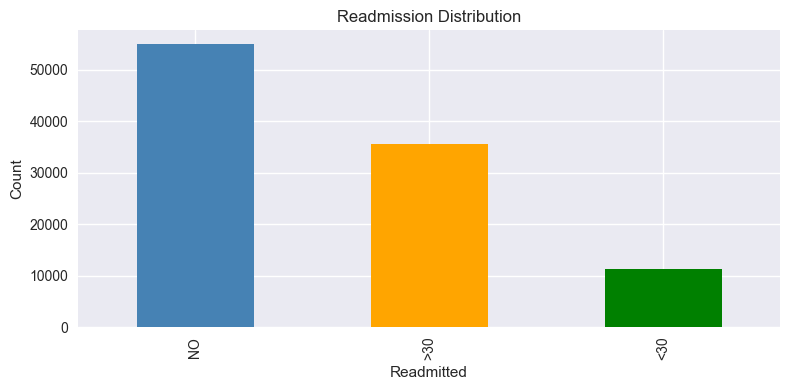

In [4]:
print(df['readmitted'].value_counts())

plt.figure(figsize=(8,4))
df['readmitted'].value_counts().plot(kind='bar', color=['steelblue','orange','green'])
plt.title('Readmission Distribution')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(REPORTS + 'readmission_distribution.png')
plt.show()

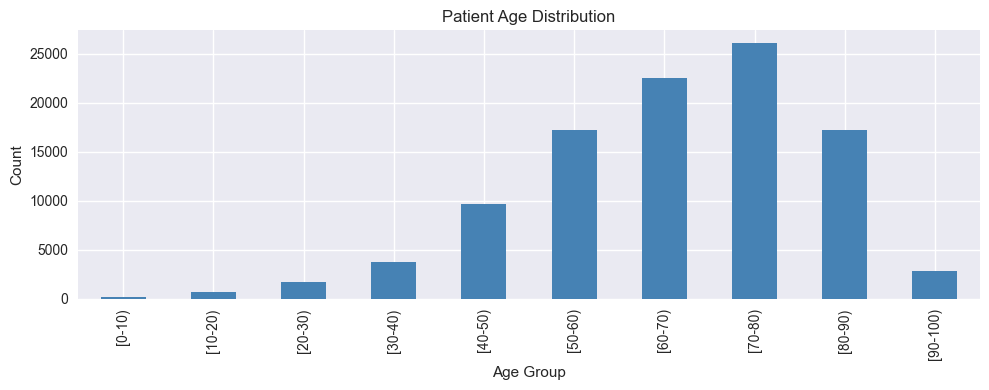

In [5]:
plt.figure(figsize=(10,4))
df['age'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Patient Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(REPORTS + 'age_distribution.png')
plt.show()

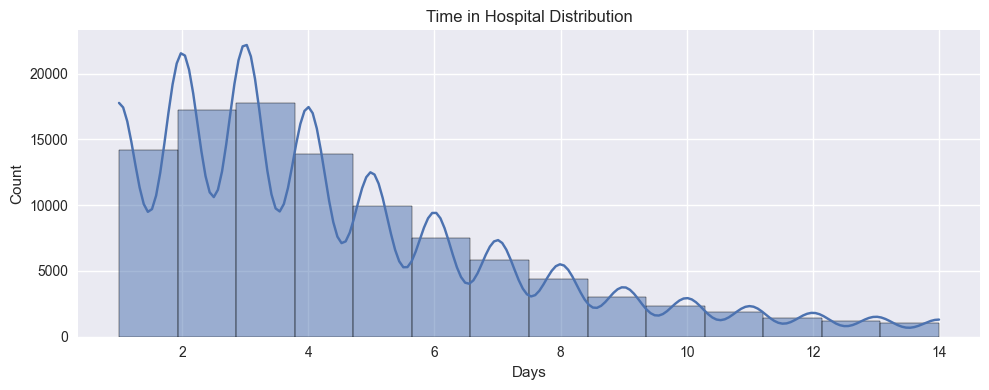

In [6]:
plt.figure(figsize=(10,4))
sns.histplot(df['time_in_hospital'], bins=14, kde=True)
plt.title('Time in Hospital Distribution')
plt.xlabel('Days')
plt.tight_layout()
plt.savefig(REPORTS + 'time_in_hospital.png')
plt.show()

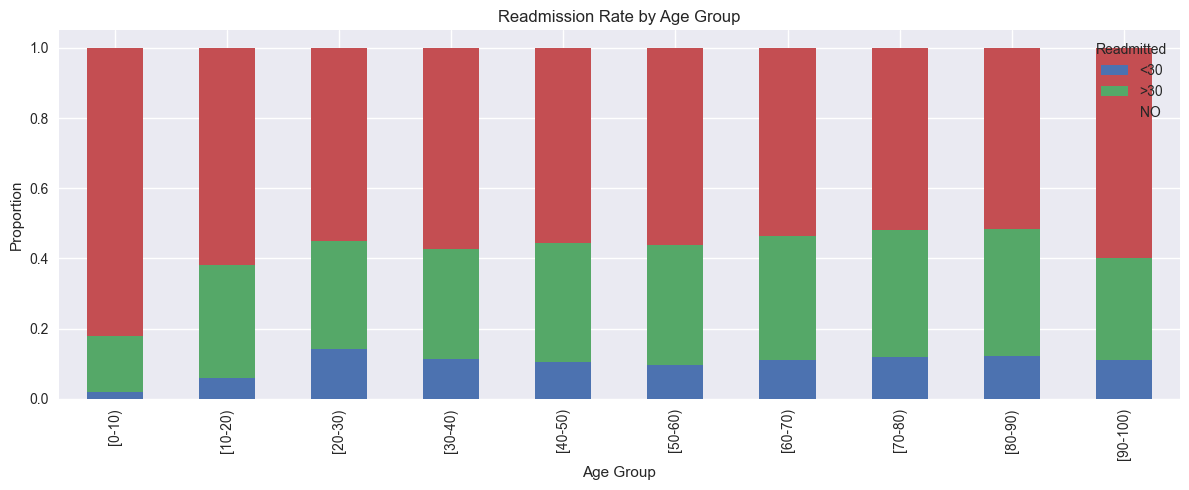

In [7]:
age_readmit = df.groupby('age')['readmitted'].value_counts(normalize=True).unstack()

age_readmit.plot(kind='bar', figsize=(12,5), stacked=True)
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.legend(title='Readmitted')
plt.tight_layout()
plt.savefig(REPORTS + 'readmission_by_age.png')
plt.show()

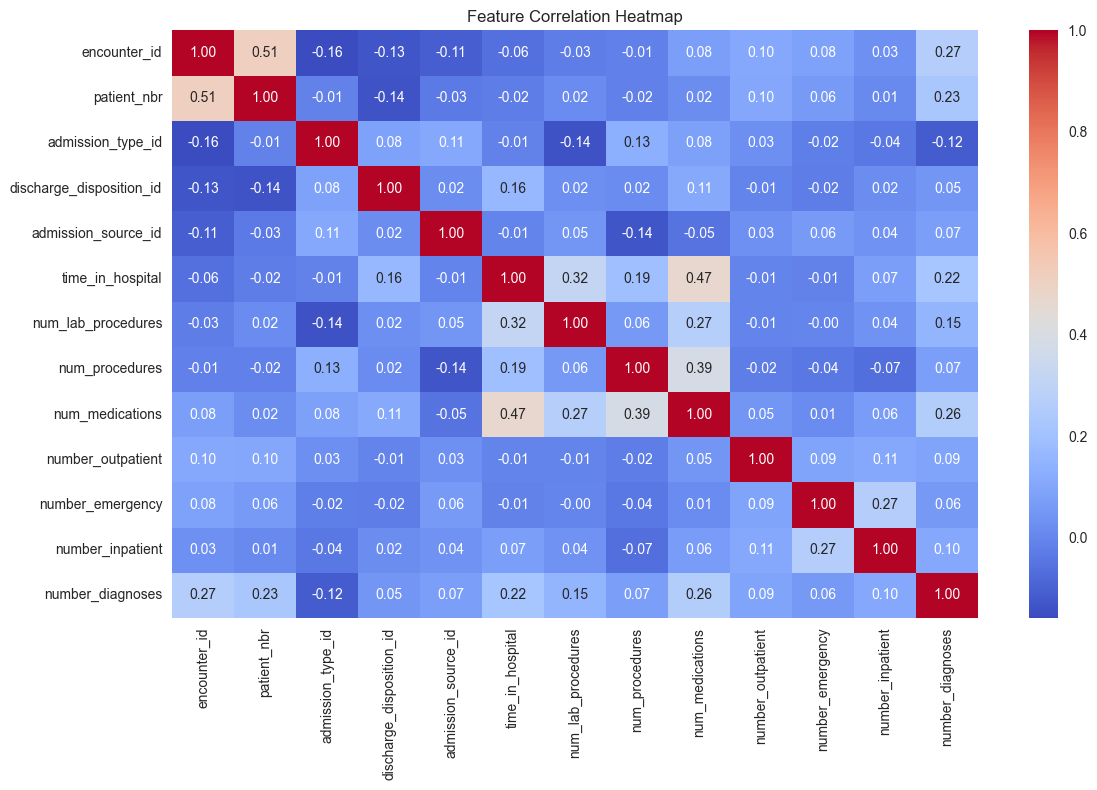

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(REPORTS + 'correlation_heatmap.png')
plt.show()

In [9]:
print("=== Key Stats ===")
print(f"Total patients: {len(df):,}")
print(f"Readmitted <30 days: {(df['readmitted']=='<30').sum():,}")
print(f"Readmitted >30 days: {(df['readmitted']=='>30').sum():,}")
print(f"Not readmitted: {(df['readmitted']=='NO').sum():,}")
print(f"Avg time in hospital: {df['time_in_hospital'].mean():.1f} days")
print(f"Avg num medications: {df['num_medications'].mean():.1f}")

=== Key Stats ===
Total patients: 101,766
Readmitted <30 days: 11,357
Readmitted >30 days: 35,545
Not readmitted: 54,864
Avg time in hospital: 4.4 days
Avg num medications: 16.0
